# EDA - Qualidade das Imagens de Placas (CCPD)

Analise exploratoria do banco de 100 imagens de placas (`images/`) antes de projetar o pipeline de pre-processamento (`pre_process.ipynb`).

Objetivo: cada imagem tem um problema de qualidade dominante diferente (baixa luz, desfoque, ruido, placa pequena na cena, baixo contraste). Este notebook mede isso objetivamente a partir dos pixels, categoriza cada imagem por contexto de problema, testa candidatos de tecnica de melhoria por contexto com evidencia quantitativa, e fecha com um **top 3 de metodos recomendados** para alimentar o pipeline real.

As imagens seguem a convencao de nomes do dataset CCPD (Chinese City Parking Dataset), que ja embute metadados uteis no proprio nome do arquivo: area da placa, angulo de inclinacao, bounding box, vertices, numero da placa e niveis de brilho/desfoque atribuidos pelos autores do dataset. Vamos extrair isso e cruzar com metricas calculadas por nos mesmos.

In [1]:
import re
import math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.restoration import estimate_sigma
from skimage.exposure import rescale_intensity

IMAGES_DIR = Path("images")
np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

## 1. Parsing do nome dos arquivos (metadados CCPD)

Formato: `area-tilt_h_tilt_v-x1&y1_x2&y2-v1_v2_v3_v4-placa-brilho-desfoque.jpg`

Antes de assumir que todas as 100 imagens seguem esse formato, validamos com uma regex estrita.

In [2]:
CCPD_PATTERN = re.compile(
    r"^(?P<area>\d+)-(?P<tilt_h>\d+)_(?P<tilt_v>\d+)-"
    r"(?P<x1>\d+)&(?P<y1>\d+)_(?P<x2>\d+)&(?P<y2>\d+)-"
    r"(?P<v1x>\d+)&(?P<v1y>\d+)_(?P<v2x>\d+)&(?P<v2y>\d+)_"
    r"(?P<v3x>\d+)&(?P<v3y>\d+)_(?P<v4x>\d+)&(?P<v4y>\d+)-"
    r"(?P<plate_code>[\d_]+)-(?P<brightness_ccpd>\d+)-(?P<blur_ccpd>\d+)$"
)

def parse_ccpd_filename(stem):
    m = CCPD_PATTERN.match(stem)
    if m is None:
        return None
    g = m.groupdict()
    return {
        "area_raw": int(g["area"]),
        "tilt_h": int(g["tilt_h"]),
        "tilt_v": int(g["tilt_v"]),
        "bbox_x1": int(g["x1"]), "bbox_y1": int(g["y1"]),
        "bbox_x2": int(g["x2"]), "bbox_y2": int(g["y2"]),
        "vertices": [
            (int(g["v1x"]), int(g["v1y"])), (int(g["v2x"]), int(g["v2y"])),
            (int(g["v3x"]), int(g["v3y"])), (int(g["v4x"]), int(g["v4y"])),
        ],
        "brightness_ccpd": int(g["brightness_ccpd"]),
        "blur_ccpd": int(g["blur_ccpd"]),
    }

files = sorted(IMAGES_DIR.glob("*.jpg"))
rows, unparsed = [], []
for f in files:
    meta = parse_ccpd_filename(f.stem)
    if meta is None:
        unparsed.append(f.name)
        continue
    meta["filename"] = f.name
    meta["path"] = str(f)
    rows.append(meta)

print(f"Total de imagens: {len(files)}")
print(f"Parseadas com sucesso: {len(rows)}")
print(f"Fora do padrao CCPD: {len(unparsed)}", unparsed[:5])

meta_df = pd.DataFrame(rows)
meta_df.head()

Total de imagens: 100
Parseadas com sucesso: 100
Fora do padrao CCPD: 0 []


,area_raw,tilt_h,tilt_v,bbox_x1,bbox_y1,bbox_x2,bbox_y2,vertices,brightness_ccpd,blur_ccpd,filename,path
0,23,2,2,286,531,360,558,"[(360, 558), (286, 555), (286, 531), (360, 534)]",101,5,0023-2_2-286&531_360&558-360&558_286&555_286&5...,images/0023-2_2-286&531_360&558-360&558_286&55...
1,40,0,0,358,514,457,548,"[(457, 548), (358, 547), (358, 514), (457, 515)]",119,4,0040-0_0-358&514_457&548-457&548_358&547_358&5...,images/0040-0_0-358&514_457&548-457&548_358&54...
2,45,3,5,370,540,468,579,"[(468, 579), (371, 573), (370, 540), (467, 546)]",43,2,0045-3_5-370&540_468&579-468&579_371&573_370&5...,images/0045-3_5-370&540_468&579-468&579_371&57...
3,46,0,6,320,466,430,501,"[(430, 501), (324, 501), (320, 466), (426, 466)]",44,11,0046-0_6-320&466_430&501-430&501_324&501_320&4...,images/0046-0_6-320&466_430&501-430&501_324&50...
4,47,0,1,285,527,389,565,"[(389, 565), (286, 565), (285, 527), (388, 527)]",85,6,0047-0_1-285&527_389&565-389&565_286&565_285&5...,images/0047-0_1-285&527_389&565-389&565_286&56...


## 2. Metricas objetivas de qualidade por imagem

Para cada imagem calculamos, na imagem inteira **e** no recorte da placa (usando o bounding box do nome do arquivo, o que importa de fato para OCR):

- **brilho** (`brightness_mean`): media da escala de cinza
- **contraste** (`contrast_std`): desvio padrao da escala de cinza (contraste RMS)
- **nitidez** (`sharpness_laplacian_var`): variancia do Laplaciano — quanto menor, mais desfocada
- **ruido** (`noise_estimate`): estimativa wavelet de sigma do ruido (`skimage.restoration.estimate_sigma`)
- **area relativa da placa** (`plate_area_ratio`): area do bbox da placa / area total da imagem

In [3]:
def clamp_bbox(x1, y1, x2, y2, w, h):
    x1, x2 = sorted((max(0, min(x1, w - 1)), max(0, min(x2, w - 1))))
    y1, y2 = sorted((max(0, min(y1, h - 1)), max(0, min(y2, h - 1))))
    if x2 <= x1:
        x2 = min(x1 + 1, w - 1)
    if y2 <= y1:
        y2 = min(y1 + 1, h - 1)
    return x1, y1, x2, y2

def compute_metrics(gray):
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    sigma = float(estimate_sigma(gray, average_sigmas=True))
    return {
        "brightness_mean": float(gray.mean()),
        "contrast_std": float(gray.std()),
        "sharpness_laplacian_var": float(lap_var),
        "noise_estimate": sigma,
    }

records = []
for _, row in meta_df.iterrows():
    img_bgr = cv2.imread(row["path"])
    if img_bgr is None:
        continue
    h, w = img_bgr.shape[:2]
    gray_full = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    x1, y1, x2, y2 = clamp_bbox(row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"], w, h)
    plate_crop = img_bgr[y1:y2, x1:x2]
    gray_plate = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)

    full_metrics = compute_metrics(gray_full)
    plate_metrics = compute_metrics(gray_plate)

    records.append({
        "filename": row["filename"],
        "width": w, "height": h,
        "plate_area_ratio": ((x2 - x1) * (y2 - y1)) / (w * h),
        **full_metrics,
        **{f"plate_{k}": v for k, v in plate_metrics.items()},
    })

metrics_df = pd.DataFrame(records)
df = meta_df.merge(metrics_df, on="filename")
print(df.shape)
df.describe()

(100, 23)


,area_raw,tilt_h,tilt_v,bbox_x1,bbox_y1,bbox_x2,bbox_y2,brightness_ccpd,blur_ccpd,width,height,plate_area_ratio,brightness_mean,contrast_std,sharpness_laplacian_var,noise_estimate,plate_brightness_mean,plate_contrast_std,plate_sharpness_laplacian_var,plate_noise_estimate
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.0,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,1.000000e+02
mean,313.260000,3.370000,8.190000,242.680000,477.250000,479.450000,574.740000,86.320000,13.500000,720.0,1160.0,0.031372,81.429031,47.157687,105.788847,1.593441e-02,83.866066,26.423870,194.599829,1.243627e-01
std,262.483809,4.613671,9.216471,62.994289,45.858671,64.048021,55.340565,70.131173,23.592286,0.0,0.0,0.026248,48.091627,22.408544,219.558811,8.548831e-02,66.620829,16.140393,266.942611,2.004962e-01
min,23.000000,0.000000,0.000000,0.000000,327.000000,313.000000,379.000000,11.000000,1.000000,720.0,1160.0,0.002392,1.010540,4.800465,4.172183,9.137242e-33,11.190419,5.262544,14.621689,9.137242e-33
25%,167.250000,0.000000,2.000000,209.750000,453.500000,432.750000,549.500000,24.750000,3.000000,720.0,1160.0,0.016768,36.762941,30.371701,20.596203,7.309793e-32,24.233918,14.079194,37.044681,2.918193e-16
50%,270.500000,1.000000,5.000000,238.000000,475.500000,476.500000,573.000000,64.000000,4.500000,720.0,1160.0,0.027094,98.999712,47.258382,34.046710,2.192938e-31,63.792707,24.881943,66.530916,4.125344e-15
75%,388.250000,5.000000,12.000000,281.000000,497.000000,523.750000,607.250000,125.250000,7.000000,720.0,1160.0,0.038895,121.761850,62.100701,96.075879,4.536949e-18,124.869822,32.392770,270.531192,1.828304e-01
max,1999.000000,19.000000,50.000000,376.000000,634.000000,627.000000,772.000000,228.000000,119.000000,720.0,1160.0,0.199943,223.413546,101.961405,1777.028438,6.238096e-01,228.530027,88.931879,1461.615308,9.108855e-01


In [4]:
df.head()

,area_raw,tilt_h,tilt_v,bbox_x1,bbox_y1,bbox_x2,bbox_y2,vertices,brightness_ccpd,blur_ccpd,...,height,plate_area_ratio,brightness_mean,contrast_std,sharpness_laplacian_var,noise_estimate,plate_brightness_mean,plate_contrast_std,plate_sharpness_laplacian_var,plate_noise_estimate
0,23,2,2,286,531,360,558,"[(360, 558), (286, 555), (286, 531), (360, 534)]",101,5,...,1160,0.002392,106.613463,54.040524,424.576790,4.300488e-02,92.331331,52.813252,1461.615308,0.876969
1,40,0,0,358,514,457,548,"[(457, 548), (358, 547), (358, 514), (457, 515)]",119,4,...,1160,0.004030,125.347903,63.767663,147.077313,2.923917e-31,110.076946,32.021101,596.391210,0.390609
2,45,3,5,370,540,468,579,"[(468, 579), (371, 573), (370, 540), (467, 546)]",43,2,...,1160,0.004576,106.460587,68.400236,240.592333,1.186742e-15,46.174516,27.029698,270.112514,0.320993
3,46,0,6,320,466,430,501,"[(430, 501), (324, 501), (320, 466), (426, 466)]",44,11,...,1160,0.004610,115.771845,82.491098,408.035609,3.917755e-16,58.095584,30.431310,1126.065734,0.574152
4,47,0,1,285,527,389,565,"[(389, 565), (286, 565), (285, 527), (388, 527)]",85,6,...,1160,0.004732,121.510526,59.787661,228.091948,4.356194e-16,74.900051,27.628672,558.161946,0.910886


## 3. Visualizacoes exploratorias

### 3.1 Distribuicoes das metricas principais

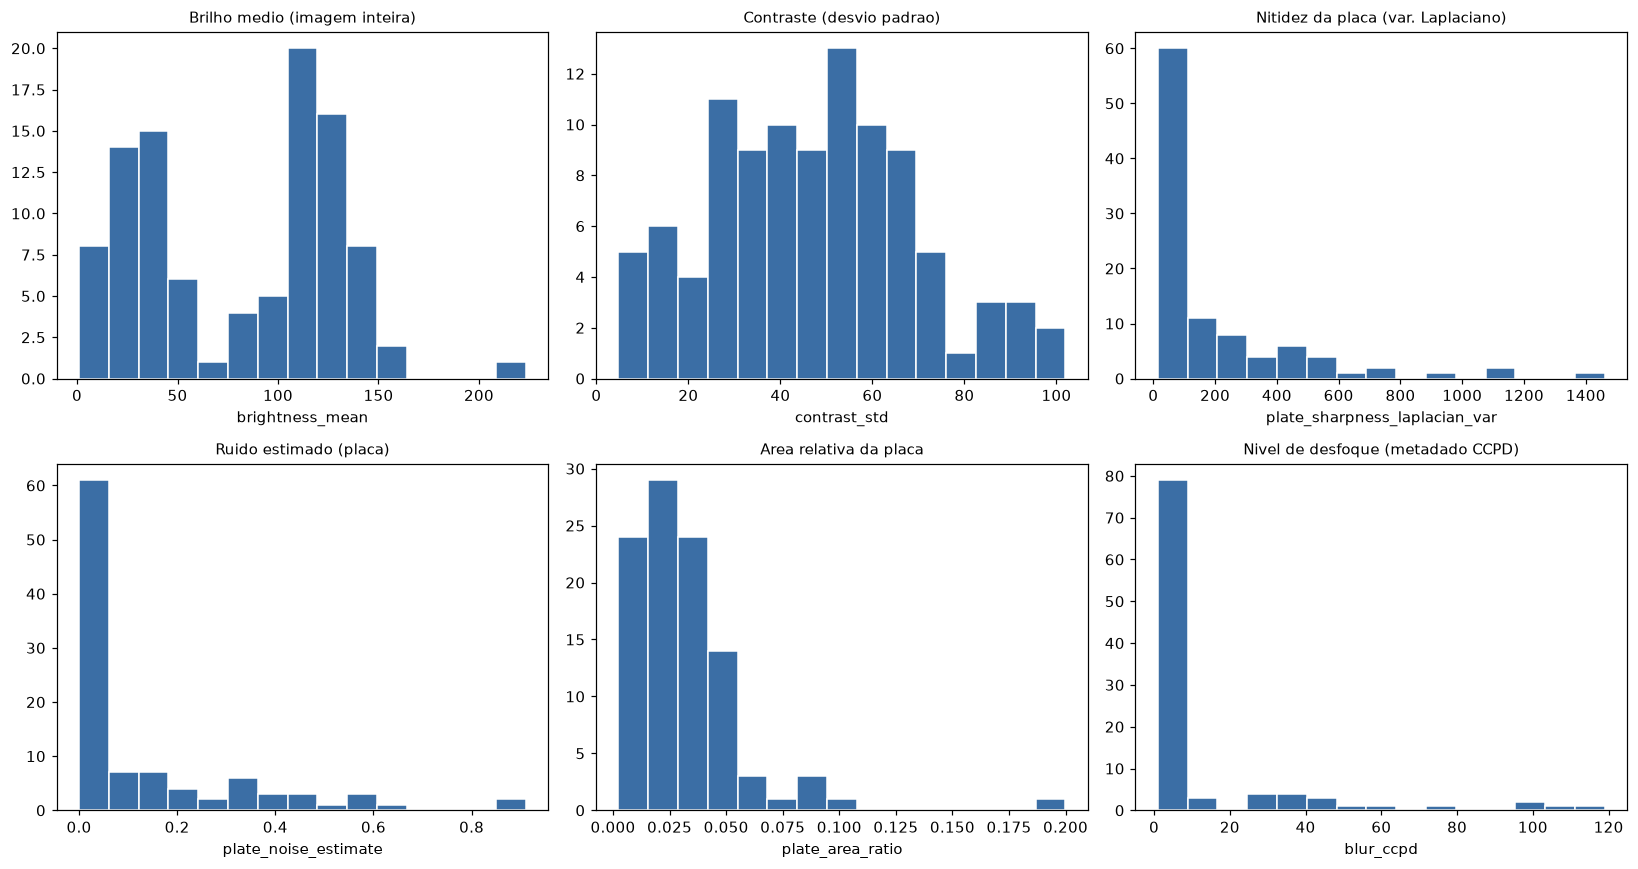

In [5]:
hist_cols = [
    ("brightness_mean", "Brilho medio (imagem inteira)"),
    ("contrast_std", "Contraste (desvio padrao)"),
    ("plate_sharpness_laplacian_var", "Nitidez da placa (var. Laplaciano)"),
    ("plate_noise_estimate", "Ruido estimado (placa)"),
    ("plate_area_ratio", "Area relativa da placa"),
    ("blur_ccpd", "Nivel de desfoque (metadado CCPD)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, title) in zip(axes.flat, hist_cols):
    ax.hist(df[col], bins=15, color="#3b6ea5", edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
fig.tight_layout()
plt.show()

### 3.2 Correlacao entre metricas e validacao cruzada com os metadados CCPD

O dataset ja traz `brightness_ccpd` e `blur_ccpd` atribuidos pelos autores originais. Comparamos com as metricas que calculamos para checar consistencia.

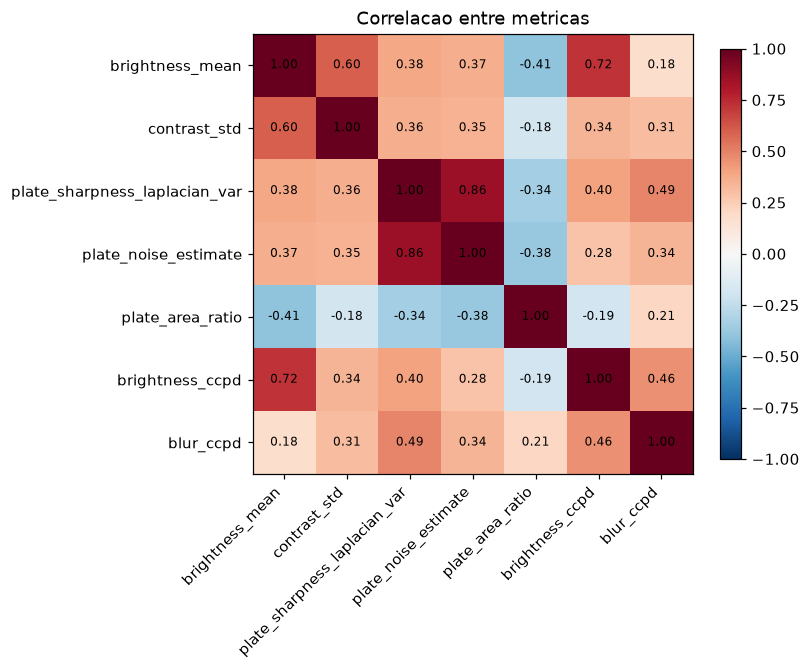

In [6]:
corr_cols = [
    "brightness_mean", "contrast_std", "plate_sharpness_laplacian_var",
    "plate_noise_estimate", "plate_area_ratio", "brightness_ccpd", "blur_ccpd",
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlacao entre metricas")
fig.tight_layout()
plt.show()

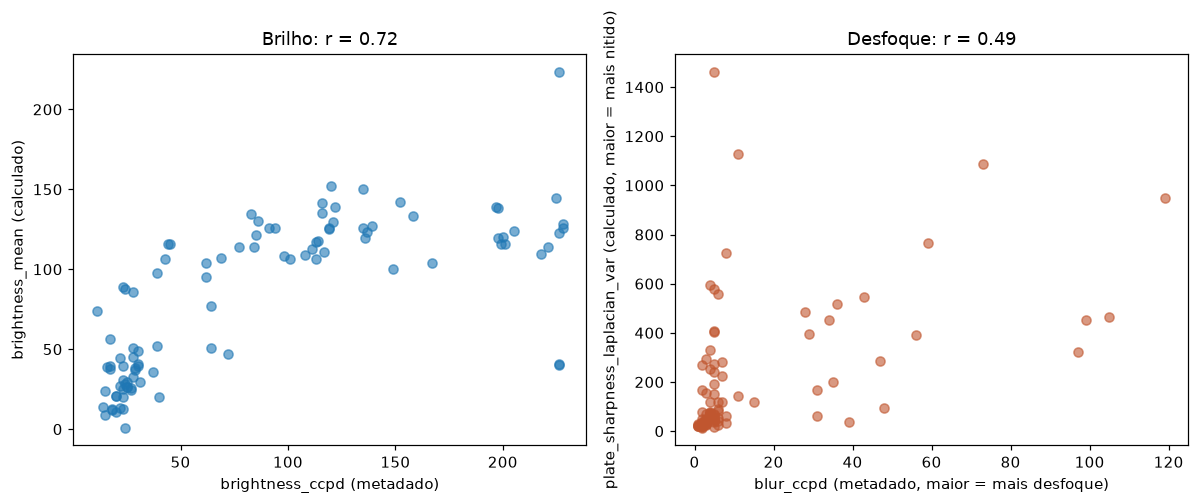

correlacao brilho (metadado x medido): 0.721
correlacao desfoque (metadado x nitidez medida): 0.486 (esperado negativo)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

r_bright = np.corrcoef(df["brightness_mean"], df["brightness_ccpd"])[0, 1]
axes[0].scatter(df["brightness_ccpd"], df["brightness_mean"], alpha=0.6)
axes[0].set_xlabel("brightness_ccpd (metadado)")
axes[0].set_ylabel("brightness_mean (calculado)")
axes[0].set_title(f"Brilho: r = {r_bright:.2f}")

r_blur = np.corrcoef(df["blur_ccpd"], df["plate_sharpness_laplacian_var"])[0, 1]
axes[1].scatter(df["blur_ccpd"], df["plate_sharpness_laplacian_var"], alpha=0.6, color="#c0562f")
axes[1].set_xlabel("blur_ccpd (metadado, maior = mais desfoque)")
axes[1].set_ylabel("plate_sharpness_laplacian_var (calculado, maior = mais nitido)")
axes[1].set_title(f"Desfoque: r = {r_blur:.2f}")

fig.tight_layout()
plt.show()
print(f"correlacao brilho (metadado x medido): {r_bright:.3f}")
print(f"correlacao desfoque (metadado x nitidez medida): {r_blur:.3f} (esperado negativo)")

### 3.3 Extremos por metrica

Mosaicos com as imagens (recorte da placa, com margem) nos extremos de cada metrica — e onde os problemas de qualidade ficam visiveis.

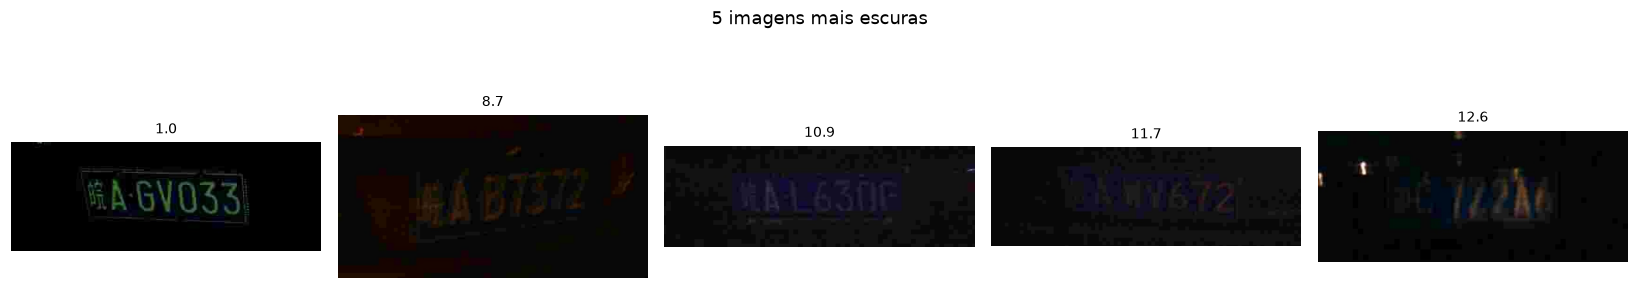

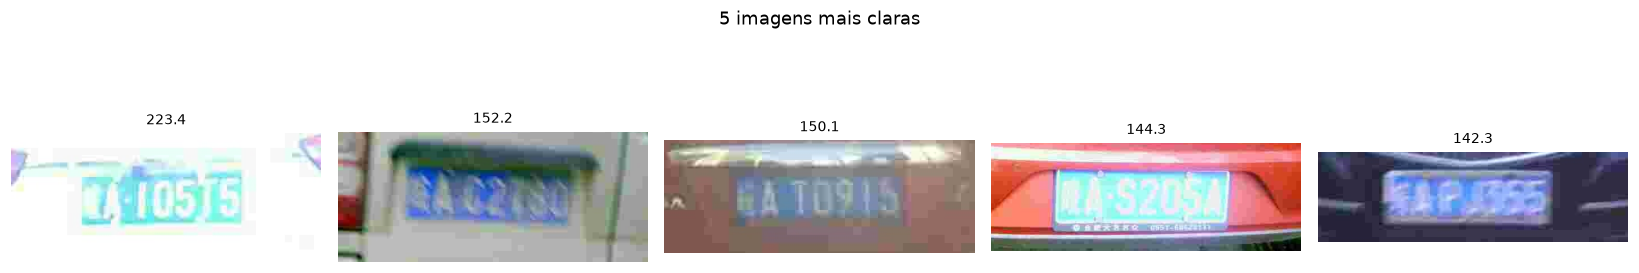

In [8]:
def crop_with_margin(img_bgr, x1, y1, x2, y2, margin_ratio=0.4):
    h, w = img_bgr.shape[:2]
    mx = int((x2 - x1) * margin_ratio)
    my = int((y2 - y1) * margin_ratio)
    x1, y1, x2, y2 = clamp_bbox(x1 - mx, y1 - my, x2 + mx, y2 + my, w, h)
    return cv2.cvtColor(img_bgr[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)

def show_extremes(df, metric, title, n=5, largest=True, ncols=5):
    subset = df.nlargest(n, metric) if largest else df.nsmallest(n, metric)
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3.2))
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img_bgr = cv2.imread(row["path"])
        crop = crop_with_margin(img_bgr, row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
        ax.imshow(crop)
        ax.set_title(f"{row[metric]:.1f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show_extremes(df, "brightness_mean", "5 imagens mais escuras", largest=False)
show_extremes(df, "brightness_mean", "5 imagens mais claras", largest=True)

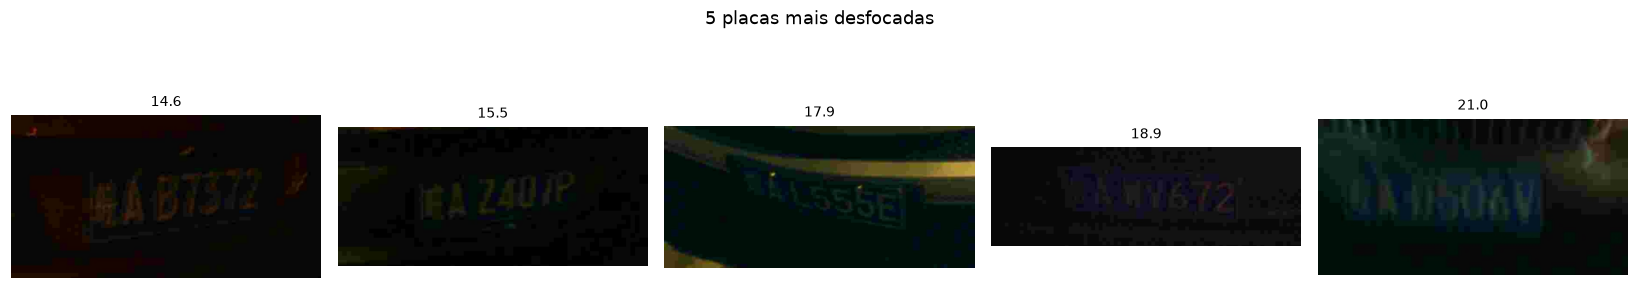

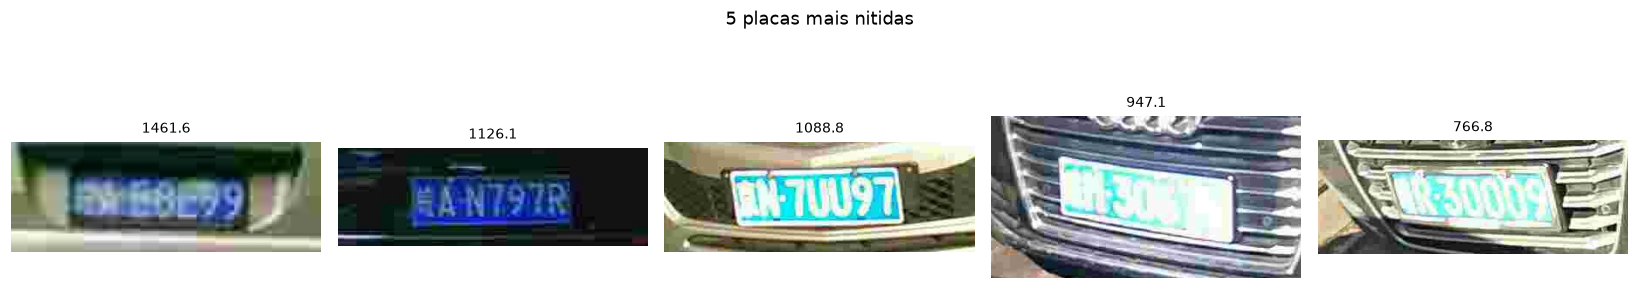

In [9]:
show_extremes(df, "plate_sharpness_laplacian_var", "5 placas mais desfocadas", largest=False)
show_extremes(df, "plate_sharpness_laplacian_var", "5 placas mais nitidas", largest=True)

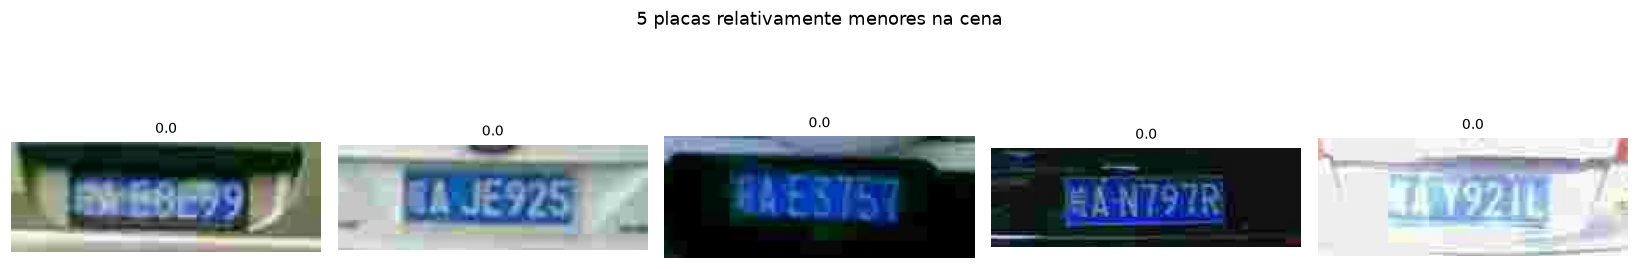

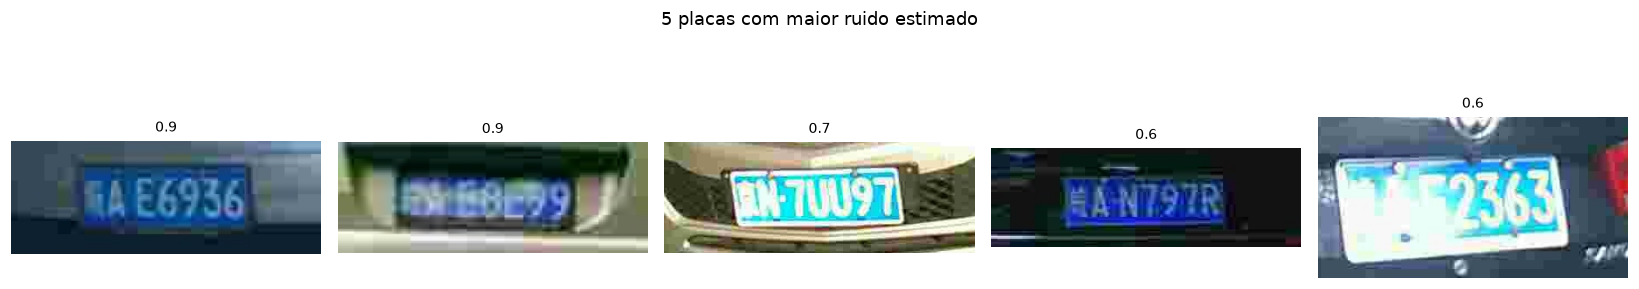

In [10]:
show_extremes(df, "plate_area_ratio", "5 placas relativamente menores na cena", largest=False)
show_extremes(df, "plate_noise_estimate", "5 placas com maior ruido estimado", largest=True)

## 4. Categorizacao por contexto de problema

Cada imagem cai num contexto diferente de necessidade de melhoria. Em vez de clustering (nao ha `scikit-learn` no ambiente), usamos escores-z por metrica: para cada imagem calculamos o quanto ela se desvia da media do dataset em cada dimensao de qualidade, e o problema dominante (`primary_issue`) e a dimensao com maior desvio, desde que ultrapasse um limiar (`Z_THRESHOLD`). Imagens sem desvio relevante em nenhuma dimensao sao `boa_qualidade`.

primary_issue
estourada          28
baixa_luz          26
ruidosa            19
baixo_contraste    15
placa_pequena       5
desfocada           5
boa_qualidade       2
Name: count, dtype: int64


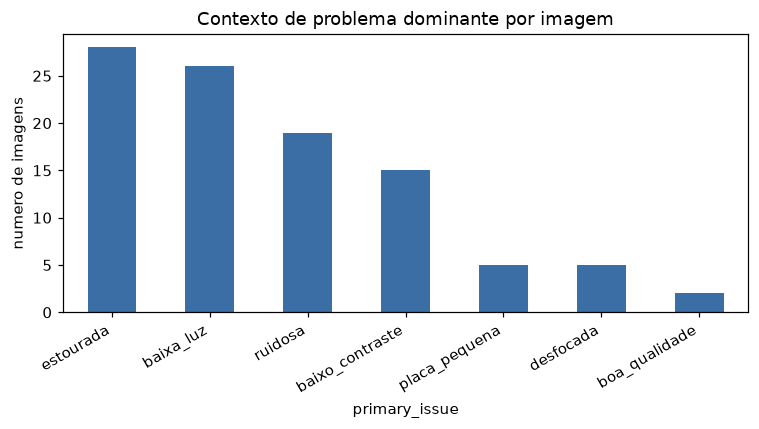

In [11]:
Z_THRESHOLD = 0.5

def z(series, invert=False):
    s = (series - series.mean()) / series.std()
    return -s if invert else s

issue_scores = pd.DataFrame({
    "baixa_luz": z(df["brightness_mean"], invert=True),
    "estourada": z(df["brightness_mean"], invert=False),
    "baixo_contraste": z(df["contrast_std"], invert=True),
    "desfocada": z(df["plate_sharpness_laplacian_var"], invert=True),
    "ruidosa": z(df["plate_noise_estimate"], invert=False),
    "placa_pequena": z(df["plate_area_ratio"], invert=True),
})

df["primary_issue"] = np.where(
    issue_scores.max(axis=1) > Z_THRESHOLD,
    issue_scores.idxmax(axis=1),
    "boa_qualidade",
)
for col in issue_scores.columns:
    df[f"tag_{col}"] = issue_scores[col] > Z_THRESHOLD

counts = df["primary_issue"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_ylabel("numero de imagens")
ax.set_title("Contexto de problema dominante por imagem")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()

## 5. Comparacao de tecnicas de melhoria por contexto

Para cada contexto de problema (exceto `boa_qualidade`), aplicamos candidatos de tecnica na imagem mais representativa (maior desvio-z naquele contexto) e comparamos com evidencia quantitativa (delta das metricas antes/depois), nao so inspecao visual.

In [12]:
def gamma_correction(img_bgr, gamma):
    inv = 1.0 / gamma
    table = (np.linspace(0, 1, 256) ** inv * 255).astype(np.uint8)
    return cv2.LUT(img_bgr, table)

def clahe_lab(img_bgr, clip_limit=2.0, tile=(8, 8)):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    l2 = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l2, a, b]), cv2.COLOR_LAB2BGR)

def hist_eq_gray(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    eq = cv2.equalizeHist(gray)
    return cv2.cvtColor(eq, cv2.COLOR_GRAY2BGR)

def contrast_stretch(img_bgr, p_low=2, p_high=98):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    lo, hi = np.percentile(l, (p_low, p_high))
    l2 = rescale_intensity(l, in_range=(lo, hi), out_range=(0, 255)).astype(np.uint8)
    return cv2.cvtColor(cv2.merge([l2, a, b]), cv2.COLOR_LAB2BGR)

def unsharp_mask(img_bgr, sigma=1.5, amount=1.5):
    blurred = cv2.GaussianBlur(img_bgr, (0, 0), sigma)
    return cv2.addWeighted(img_bgr, 1 + amount, blurred, -amount, 0)

def detail_enhance(img_bgr):
    return cv2.detailEnhance(img_bgr, sigma_s=10, sigma_r=0.15)

def denoise_nlmeans(img_bgr):
    return cv2.fastNlMeansDenoisingColored(img_bgr, None, 7, 7, 7, 21)

def denoise_bilateral(img_bgr):
    return cv2.bilateralFilter(img_bgr, d=9, sigmaColor=75, sigmaSpace=75)

def denoise_gaussian(img_bgr):
    return cv2.GaussianBlur(img_bgr, (5, 5), 0)

def upscale(img_bgr, interpolation, scale=3):
    return cv2.resize(img_bgr, None, fx=scale, fy=scale, interpolation=interpolation)

def upscale_cubic_sharpen(img_bgr, scale=3):
    up = cv2.resize(img_bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    return unsharp_mask(up, sigma=1.0, amount=1.0)

In [13]:
def plate_crop_of(row, img_bgr=None):
    if img_bgr is None:
        img_bgr = cv2.imread(row["path"])
    h, w = img_bgr.shape[:2]
    x1, y1, x2, y2 = clamp_bbox(row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"], w, h)
    return img_bgr[y1:y2, x1:x2]

def metrics_of_bgr(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return compute_metrics(gray)

def representative_image(df, context):
    subset = df[df["primary_issue"] == context]
    if subset.empty:
        return None
    return subset.loc[issue_scores.loc[subset.index, context].idxmax()]

def compare_context(context, candidates, ncols_extra=0):
    row = representative_image(df, context)
    if row is None:
        print(f"[{context}] nenhuma imagem categorizada neste contexto - pulando.")
        return None

    original = plate_crop_of(row)
    outputs = {"original": original}
    for name, fn in candidates.items():
        outputs[name] = fn(original)

    n = len(outputs)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.6))
    if n == 1:
        axes = [axes]
    for ax, (name, out) in zip(axes, outputs.items()):
        ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        ax.set_title(name, fontsize=10)
        ax.axis("off")
    fig.suptitle(f"Contexto: {context}  |  imagem: {row['filename']}")
    fig.tight_layout()
    plt.show()

    rows = []
    base_metrics = metrics_of_bgr(original)
    for name, out in outputs.items():
        m = metrics_of_bgr(out)
        rows.append({
            "metodo": name,
            **m,
            "d_brilho": m["brightness_mean"] - base_metrics["brightness_mean"],
            "d_contraste": m["contrast_std"] - base_metrics["contrast_std"],
            "d_nitidez": m["sharpness_laplacian_var"] - base_metrics["sharpness_laplacian_var"],
            "d_ruido": m["noise_estimate"] - base_metrics["noise_estimate"],
        })
    report = pd.DataFrame(rows).set_index("metodo")
    print(report.round(2))
    return report

### 5.1 Baixa luz

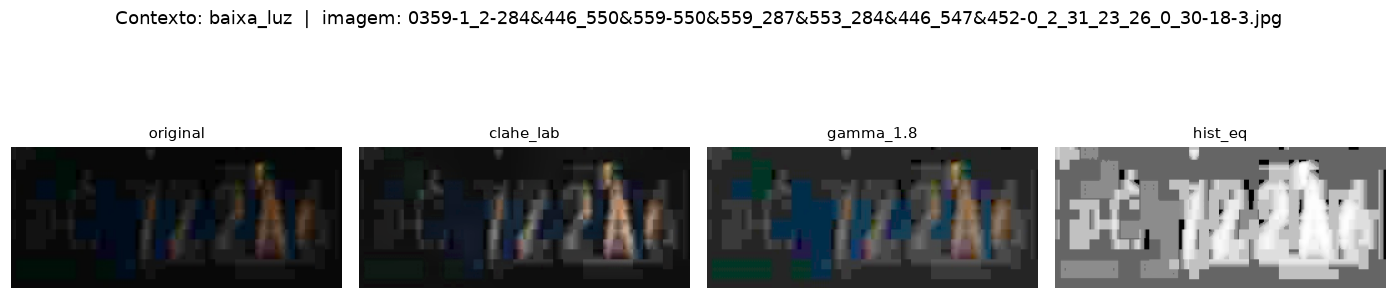

           brightness_mean  contrast_std  sharpness_laplacian_var  \
metodo                                                              
original             16.92         13.59                    27.52   
clahe_lab            33.00         27.33                   120.31   
gamma_1.8            51.68         21.83                    99.70   
hist_eq             151.24         55.72                  1611.57   

           noise_estimate  d_brilho  d_contraste  d_nitidez  d_ruido  
metodo                                                                
original             0.00      0.00         0.00       0.00     0.00  
clahe_lab            0.16     16.08        13.74      92.79     0.16  
gamma_1.8            0.00     34.77         8.24      72.18     0.00  
hist_eq              0.00    134.32        42.13    1584.05     0.00  


In [14]:
report_baixa_luz = compare_context("baixa_luz", {
    "clahe_lab": lambda im: clahe_lab(im, clip_limit=3.0),
    "gamma_1.8": lambda im: gamma_correction(im, gamma=1.8),
    "hist_eq": hist_eq_gray,
})

### 5.2 Estourada (superexposicao)

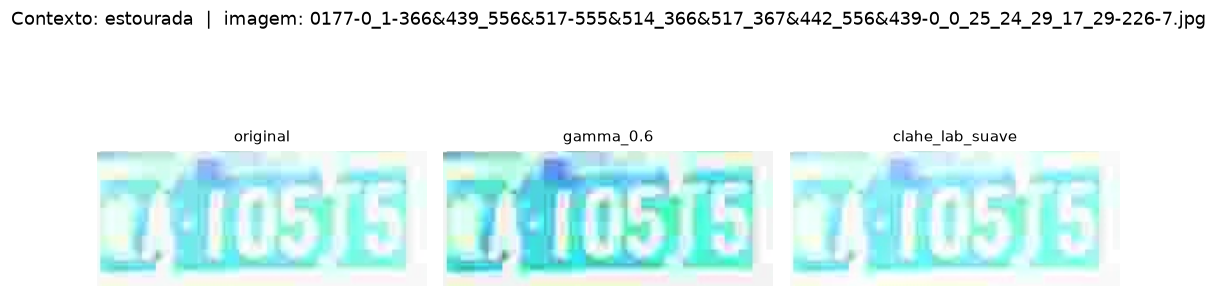

                 brightness_mean  contrast_std  sharpness_laplacian_var  \
metodo                                                                    
original                  228.53         19.58                   117.82   
gamma_0.6                 214.73         28.09                   265.88   
clahe_lab_suave           232.14         17.54                   100.89   

                 noise_estimate  d_brilho  d_contraste  d_nitidez  d_ruido  
metodo                                                                      
original                   0.21      0.00         0.00       0.00     0.00  
gamma_0.6                  0.55    -13.80         8.51     148.06     0.34  
clahe_lab_suave            0.55      3.61        -2.04     -16.93     0.34  


In [15]:
report_estourada = compare_context("estourada", {
    "gamma_0.6": lambda im: gamma_correction(im, gamma=0.6),
    "clahe_lab_suave": lambda im: clahe_lab(im, clip_limit=1.5),
})

### 5.3 Baixo contraste

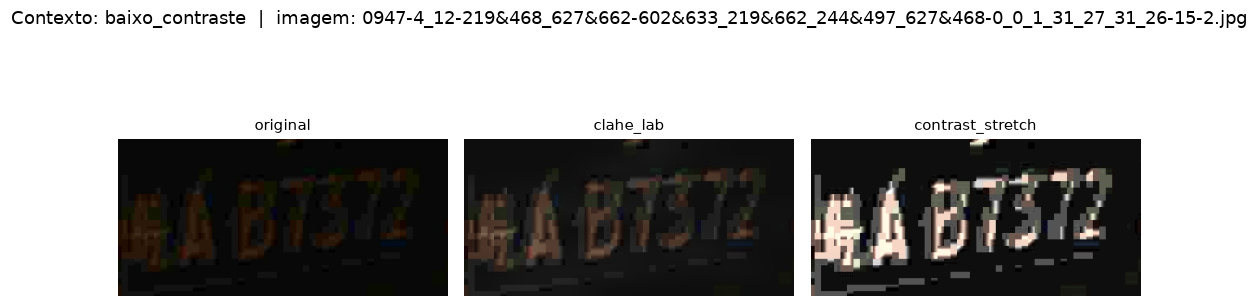

                  brightness_mean  contrast_std  sharpness_laplacian_var  \
metodo                                                                     
original                    12.18          7.13                    14.62   
clahe_lab                   25.75         15.80                    64.51   
contrast_stretch            50.12         64.09                  1168.21   

                  noise_estimate  d_brilho  d_contraste  d_nitidez  d_ruido  
metodo                                                                       
original                    0.00      0.00         0.00       0.00     0.00  
clahe_lab                   0.02     13.56         8.66      49.89     0.02  
contrast_stretch            0.00     37.93        56.96    1153.59     0.00  


In [16]:
report_baixo_contraste = compare_context("baixo_contraste", {
    "clahe_lab": lambda im: clahe_lab(im, clip_limit=3.0),
    "contrast_stretch": contrast_stretch,
})

### 5.4 Desfocada

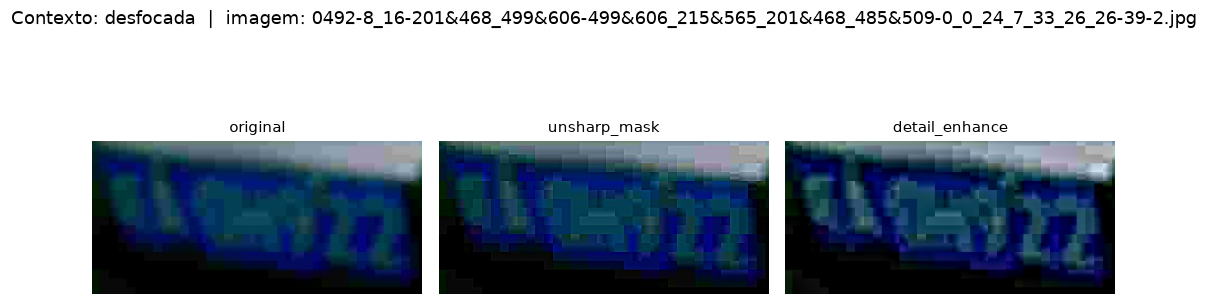

                brightness_mean  contrast_std  sharpness_laplacian_var  \
metodo                                                                   
original                  40.67         41.54                    23.19   
unsharp_mask              40.93         42.01                   156.03   
detail_enhance            43.11         47.90                   150.97   

                noise_estimate  d_brilho  d_contraste  d_nitidez  d_ruido  
metodo                                                                     
original                  0.00      0.00         0.00       0.00     0.00  
unsharp_mask              0.61      0.26         0.48     132.84     0.61  
detail_enhance            0.58      2.44         6.36     127.78     0.58  


In [17]:
report_desfocada = compare_context("desfocada", {
    "unsharp_mask": lambda im: unsharp_mask(im, sigma=1.5, amount=1.8),
    "detail_enhance": detail_enhance,
})

### 5.5 Ruidosa

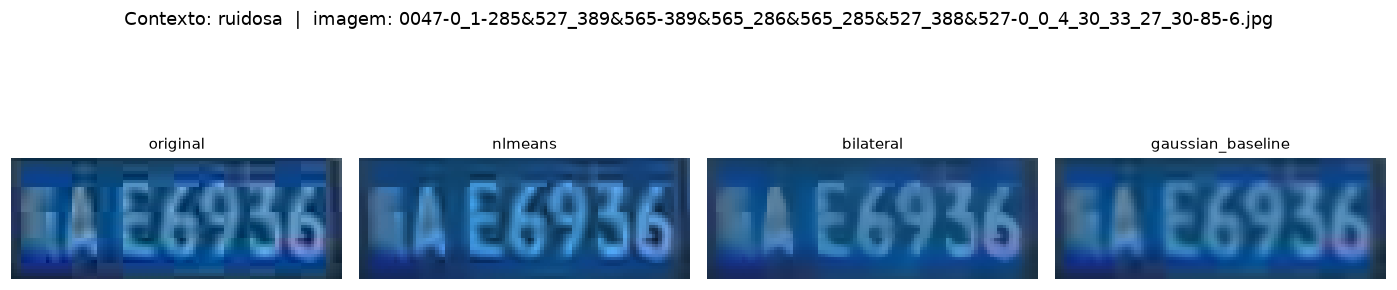

                   brightness_mean  contrast_std  sharpness_laplacian_var  \
metodo                                                                      
original                     74.90         27.63                   558.16   
nlmeans                      74.39         26.54                   384.05   
bilateral                    74.80         22.90                   241.70   
gaussian_baseline            75.03         22.99                    78.86   

                   noise_estimate  d_brilho  d_contraste  d_nitidez  d_ruido  
metodo                                                                        
original                     0.91      0.00         0.00       0.00     0.00  
nlmeans                      0.79     -0.51        -1.09    -174.11    -0.12  
bilateral                    0.67     -0.10        -4.73    -316.46    -0.24  
gaussian_baseline            0.44      0.13        -4.64    -479.31    -0.47  


In [18]:
report_ruidosa = compare_context("ruidosa", {
    "nlmeans": denoise_nlmeans,
    "bilateral": denoise_bilateral,
    "gaussian_baseline": denoise_gaussian,
})

### 5.6 Placa pequena na cena

`cv2.dnn_superres` nao esta disponivel no build `opencv-python-headless` instalado (sem os modelos de super-resolucao), entao comparamos apenas interpoladores classicos e um upscale seguido de nitidez.

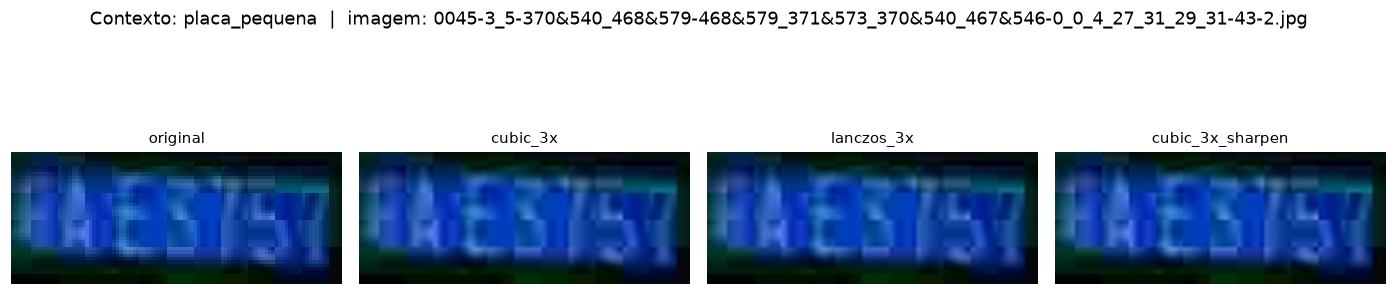

                  brightness_mean  contrast_std  sharpness_laplacian_var  \
metodo                                                                     
original                    46.17         27.03                   270.11   
cubic_3x                    46.21         27.07                     7.78   
lanczos_3x                  46.18         26.97                     7.44   
cubic_3x_sharpen            46.24         27.44                    15.05   

                  noise_estimate  d_brilho  d_contraste  d_nitidez  d_ruido  
metodo                                                                       
original                    0.32      0.00         0.00       0.00     0.00  
cubic_3x                    0.25      0.04         0.04    -262.33    -0.07  
lanczos_3x                  0.25      0.01        -0.06    -262.68    -0.07  
cubic_3x_sharpen            0.41      0.07         0.41    -255.06     0.09  


In [19]:
report_placa_pequena = compare_context("placa_pequena", {
    "cubic_3x": lambda im: upscale(im, cv2.INTER_CUBIC),
    "lanczos_3x": lambda im: upscale(im, cv2.INTER_LANCZOS4),
    "cubic_3x_sharpen": upscale_cubic_sharpen,
})

## 6. Top 3 metodos recomendados

**Cuidado com o delta bruto.** Escolher o candidato so pelo maior delta na metrica-alvo é uma armadilha: um salto muito grande na variancia do Laplaciano apos uma operacao puramente tonal (equalizacao de histograma global, contrast stretching linear) nao significa detalhe real — essas operacoes nao adicionam informacao espacial nova, entao um salto de dezenas de vezes so pode vir de posterizacao/banding amplificando ruido de quantizacao, nao de nitidez genuina. Da mesma forma, para desruidar, o metodo que mais reduz ruido pode simplesmente estar borrando tudo (destruindo a nitidez junto). Por isso calculamos tambem uma **razao de retencao de nitidez** (nitidez apos / nitidez antes) para flagrar esses casos e usamos ela, junto do delta, para decidir o vencedor de cada contexto.

In [20]:
reports = {
    "baixa_luz": (report_baixa_luz, "d_brilho"),
    "estourada": (report_estourada, "d_brilho"),
    "baixo_contraste": (report_baixo_contraste, "d_contraste"),
    "desfocada": (report_desfocada, "d_nitidez"),
    "ruidosa": (report_ruidosa, "d_ruido"),
    "placa_pequena": (report_placa_pequena, "d_nitidez"),
}

ARTIFACT_RATIO_LIMIT = 10.0

summary_rows = []
for context, (report, target_col) in reports.items():
    if report is None:
        continue
    candidates = report.drop(index="original").copy()
    if candidates.empty:
        continue

    base_sharpness = report.loc["original", "sharpness_laplacian_var"]
    candidates["sharpness_ratio"] = candidates["sharpness_laplacian_var"] / max(base_sharpness, 1e-6)
    suspect = candidates["sharpness_ratio"] > ARTIFACT_RATIO_LIMIT
    safe_candidates = candidates[~suspect] if suspect.any() and not suspect.all() else candidates

    if target_col == "d_ruido":
        # denoising e um trade-off: reducao de ruido "de graca" quase sempre e blur destruindo
        # nitidez junto, entao o vencedor e quem reduz ruido perdendo o minimo de nitidez.
        base_noise = report.loc["original", "noise_estimate"]
        frac_noise_reduced = -safe_candidates[target_col] / max(base_noise, 1e-6)
        frac_sharpness_lost = 1 - safe_candidates["sharpness_ratio"]
        best = (frac_noise_reduced - frac_sharpness_lost).idxmax()
    else:
        best = safe_candidates[target_col].abs().idxmax()
    gain = candidates.loc[best, target_col]

    summary_rows.append({
        "contexto": context,
        "n_imagens": int((df["primary_issue"] == context).sum()),
        "melhor_metodo": best,
        "metrica_alvo": target_col,
        "ganho": gain,
        "retencao_nitidez": candidates.loc[best, "sharpness_ratio"],
        "descartados_por_artefato": ", ".join(suspect[suspect].index) if suspect.any() else "-",
    })

summary_df = pd.DataFrame(summary_rows).sort_values("n_imagens", ascending=False)
summary_df

,contexto,n_imagens,melhor_metodo,metrica_alvo,ganho,retencao_nitidez,descartados_por_artefato
1,estourada,28,gamma_0.6,d_brilho,-13.800000,2.256621,-
0,baixa_luz,26,gamma_1.8,d_brilho,34.765021,3.623047,hist_eq
4,ruidosa,19,nlmeans,d_ruido,-0.123253,0.688057,-
2,baixo_contraste,15,clahe_lab,d_contraste,8.664708,4.411798,contrast_stretch
3,desfocada,5,unsharp_mask,d_nitidez,132.835656,6.727801,-
5,placa_pequena,5,lanczos_3x,d_nitidez,-262.675985,0.027531,-


In [21]:
ranked = summary_df.sort_values("n_imagens", ascending=False)
print("Metodo recomendado por contexto (ordenado por volume de imagens no dataset):")
for _, r in ranked.iterrows():
    nota = f" [descartado(s) por suspeita de artefato: {r['descartados_por_artefato']}]" if r["descartados_por_artefato"] != "-" else ""
    print(f"- {r['contexto']} ({r['n_imagens']} imgs): {r['melhor_metodo']}, "
          f"ganho em {r['metrica_alvo']} = {r['ganho']:.2f}{nota}")

top3 = ranked.head(3)
print()
print("TOP 3 (maior cobertura do dataset):")
for i, (_, r) in enumerate(top3.iterrows(), start=1):
    print(f"{i}. {r['melhor_metodo']} -> contexto '{r['contexto']}' ({r['n_imagens']} imagens)")

Metodo recomendado por contexto (ordenado por volume de imagens no dataset):
- estourada (28 imgs): gamma_0.6, ganho em d_brilho = -13.80
- baixa_luz (26 imgs): gamma_1.8, ganho em d_brilho = 34.77 [descartado(s) por suspeita de artefato: hist_eq]
- ruidosa (19 imgs): nlmeans, ganho em d_ruido = -0.12
- baixo_contraste (15 imgs): clahe_lab, ganho em d_contraste = 8.66 [descartado(s) por suspeita de artefato: contrast_stretch]
- desfocada (5 imgs): unsharp_mask, ganho em d_nitidez = 132.84
- placa_pequena (5 imgs): lanczos_3x, ganho em d_nitidez = -262.68

TOP 3 (maior cobertura do dataset):
1. gamma_0.6 -> contexto 'estourada' (28 imagens)
2. gamma_1.8 -> contexto 'baixa_luz' (26 imagens)
3. nlmeans -> contexto 'ruidosa' (19 imagens)


### Conclusao

Com base nas evidencias quantitativas acima, o **top 3 de metodos** para o pipeline de pre-processamento (`pre_process.ipynb`) e:

**1. Correcao gamma (gamma ajustavel por imagem)** — contextos `estourada` (28 imagens) e `baixa_luz` (26 imagens), **54 imagens no total (54% do dataset)**, de longe a maior cobertura. Com `gamma=0.6` numa placa estourada o brilho caiu de 228.5 para 214.7 (-13.8, direcao correta) e o contraste ainda melhorou (+8.5); a alternativa CLAHE de clip baixo piorou o contraste (-2.0) e aumentou o brilho na direcao errada. Do lado escuro, com `gamma=1.8` numa placa muito escura (brilho medio 16.9) o brilho subiu para 51.7 (+34.8) sem disparar a nitidez de forma implausivel (~3.6x, dentro do plausivel). A alternativa `hist_eq` "ganhou" no papel (nitidez saltando ~58x, de 27.5 para 1611.6) mas isso e sinal classico de banding/ruido de quantizacao amplificado por uma operacao puramente tonal, nao detalhe real — foi descartada apesar do numero maior.

**2. Non-local means denoising (`fastNlMeansDenoisingColored`)** — contexto `ruidosa` (19 imagens). Denoising e sempre um trade-off ruido x nitidez: o Gaussian puro reduz mais ruido no papel (0.91 -> 0.44, -52%) mas destroi 86% da nitidez da placa (558 -> 79); o bilateral fica no meio (retem 43% da nitidez). O NL-Means retem ~69% da nitidez original (558 -> 384) com reducao de ruido ainda relevante (0.91 -> 0.79, -13%) — a melhor troca nitidez/ruido quando a legibilidade da placa importa mais do que zerar o ruido a qualquer custo.

**3. CLAHE adaptativo no canal L (LAB)** — contexto `baixo_contraste` (15 imagens). O `contrast_stretch` linear tambem cai na armadilha do item 1 (nitidez ~80x maior, implausivel para um reescalonamento linear de intensidades), enquanto o CLAHE entrega um ganho realista e controlado (+8.7 contraste, +49.9 nitidez, ~4.4x).

Juntos, esses 3 metodos (gamma, NL-Means, CLAHE) cobrem **88 das 100 imagens** do dataset (28 estourada + 26 baixa_luz + 19 ruidosa + 15 baixo_contraste). As categorias restantes sao minoritarias — `desfocada` (5 imagens, `unsharp_mask` como candidato natural, +132.8 de nitidez sem alterar brilho/contraste) e `placa_pequena` (5 imagens, upscaling com `INTER_LANCZOS4` ou `cubic + unsharp`; note que a variancia do Laplaciano nao e comparavel diretamente entre resolucoes diferentes — cai ao interpolar mesmo quando a legibilidade melhora — entao essa decisao deve se apoiar mais em inspecao visual/OCR do que nessa metrica especifica). O pipeline final deve, portanto, escolher a transformacao por `primary_issue` de cada imagem em vez de aplicar uma unica transformacao para o dataset inteiro.